# 02 — Exploratory Data Analysis

**Goal:** Understand the structure, distributions, and relationships in the dataset before any feature engineering decisions are made.

**Dataset:** `data/processed/ethylene_methane.parquet`  
**Inputs:** `s01`–`s16`  
**Targets:** `methane_ppm`, `ethylene_ppm`  

**Key facts from inspection:**
- 4,178,504 rows, temporally ordered
- ~55–57% of target rows are zero (baseline/no-gas periods)
- `methane_ppm` range: 0–296.67 ppm; `ethylene_ppm` range: 0–20.00 ppm
- 104,950 tied `time_s` values (expected multi-channel behaviour)

**Rule:** Pause after this notebook and summarize what the data suggests before proceeding to feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

SEED        = 42
DATA_PATH   = Path('../data/processed/ethylene_methane.parquet')
FIG_DIR     = Path('../results/figures')
MEMO_PATH   = Path('../results/memos/02_eda_summary.md')

FIG_DIR.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

# Downsample factor for time-series plots (4.18M rows is too dense to render)
PLOT_STRIDE = 50

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape}')

# Active-gas masks
active_methane  = df['methane_ppm']  > 0
active_ethylene = df['ethylene_ppm'] > 0
active_any      = active_methane | active_ethylene
active_both     = active_methane & active_ethylene

print(f'Rows with methane_ppm  > 0 : {active_methane.sum():>10,}  ({active_methane.mean()*100:.1f}%)')
print(f'Rows with ethylene_ppm > 0 : {active_ethylene.sum():>10,}  ({active_ethylene.mean()*100:.1f}%)')
print(f'Rows with either target > 0: {active_any.sum():>10,}  ({active_any.mean()*100:.1f}%)')
print(f'Rows with both targets  > 0: {active_both.sum():>10,}  ({active_both.mean()*100:.1f}%)')

Shape: (4178504, 19)
Rows with methane_ppm  > 0 :  1,849,752  (44.3%)
Rows with ethylene_ppm > 0 :  1,802,960  (43.1%)
Rows with either target > 0:  2,804,114  (67.1%)
Rows with both targets  > 0:    848,598  (20.3%)


## 2. Target Distributions

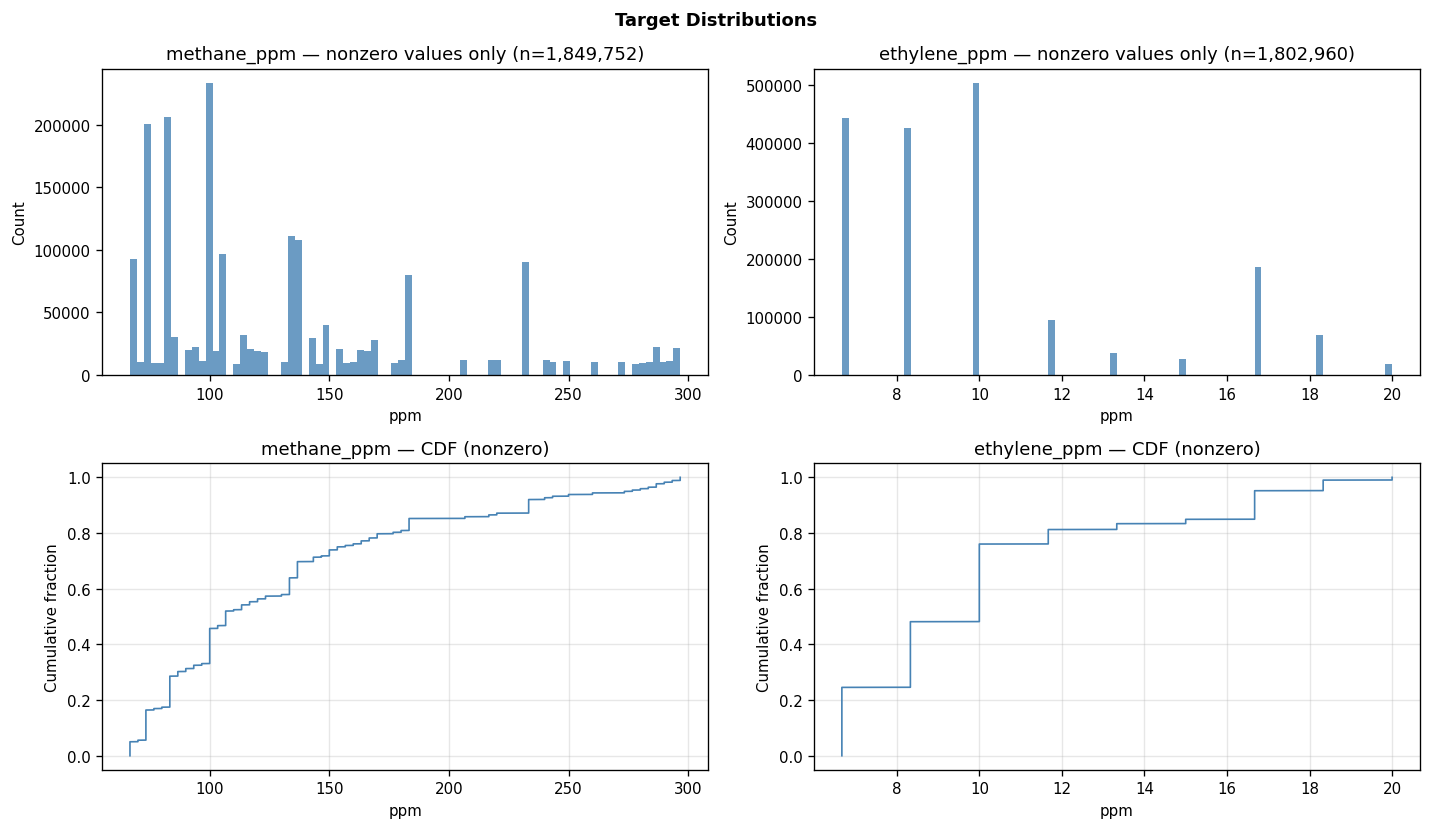

Saved: 02_target_distributions.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Target Distributions', fontweight='bold')

for col_idx, target in enumerate(TARGETS):
    # Full distribution (log scale to handle zero spike)
    ax = axes[0, col_idx]
    nonzero = df.loc[df[target] > 0, target]
    ax.hist(nonzero, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'{target} — nonzero values only (n={len(nonzero):,})')
    ax.set_xlabel('ppm')
    ax.set_ylabel('Count')

    # Cumulative distribution
    ax2 = axes[1, col_idx]
    sorted_vals = np.sort(nonzero)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax2.plot(sorted_vals, cdf, color='steelblue', linewidth=1)
    ax2.set_title(f'{target} — CDF (nonzero)')
    ax2.set_xlabel('ppm')
    ax2.set_ylabel('Cumulative fraction')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_target_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: 02_target_distributions.png')

## 3. Target Time Series (downsampled)

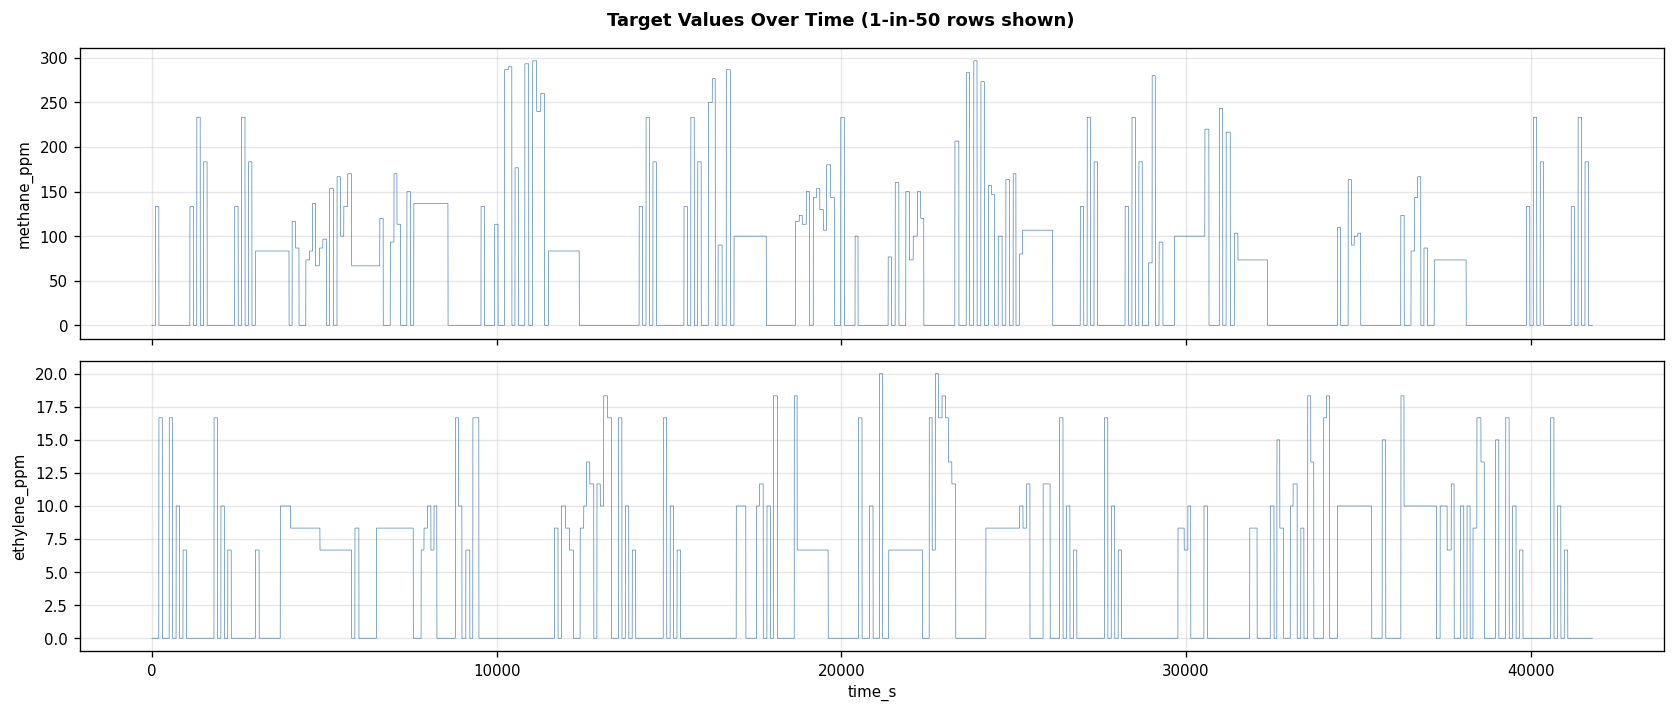

Saved: 02_target_timeseries.png


In [4]:
ds = df.iloc[::PLOT_STRIDE]  # every Nth row for plotting only

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f'Target Values Over Time (1-in-{PLOT_STRIDE} rows shown)', fontweight='bold')

for ax, target in zip(axes, TARGETS):
    ax.plot(ds[TIME], ds[target], linewidth=0.4, color='steelblue', rasterized=True)
    ax.set_ylabel(target)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('time_s')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_target_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 02_target_timeseries.png')

## 4. Baseline vs Active Periods (Regime Map)

C:\Users\User\AppData\Local\Temp\ipykernel_4164\1153470542.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 4)


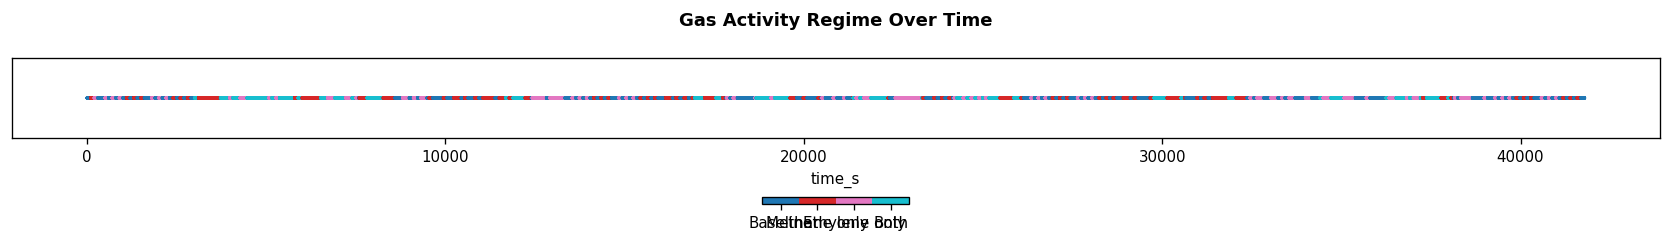

Saved: 02_regime_map.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 2))
fig.suptitle('Gas Activity Regime Over Time', fontweight='bold')

# Encode: 0=baseline, 1=methane only, 2=ethylene only, 3=both
regime = (active_methane.astype(int) + active_ethylene.astype(int) * 2)
ds_regime = regime.iloc[::PLOT_STRIDE]

cmap = plt.cm.get_cmap('tab10', 4)
sc = ax.scatter(ds[TIME], np.zeros(len(ds_regime)), c=ds_regime.values,
                cmap=cmap, vmin=0, vmax=3, s=0.5, rasterized=True)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', fraction=0.05, pad=0.4)
cbar.set_ticks([0.375, 1.125, 1.875, 2.625])
cbar.set_ticklabels(['Baseline', 'Methane only', 'Ethylene only', 'Both'])
ax.set_xlabel('time_s')
ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / '02_regime_map.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 02_regime_map.png')

## 5. Sensor Time Series (downsampled, all 16)

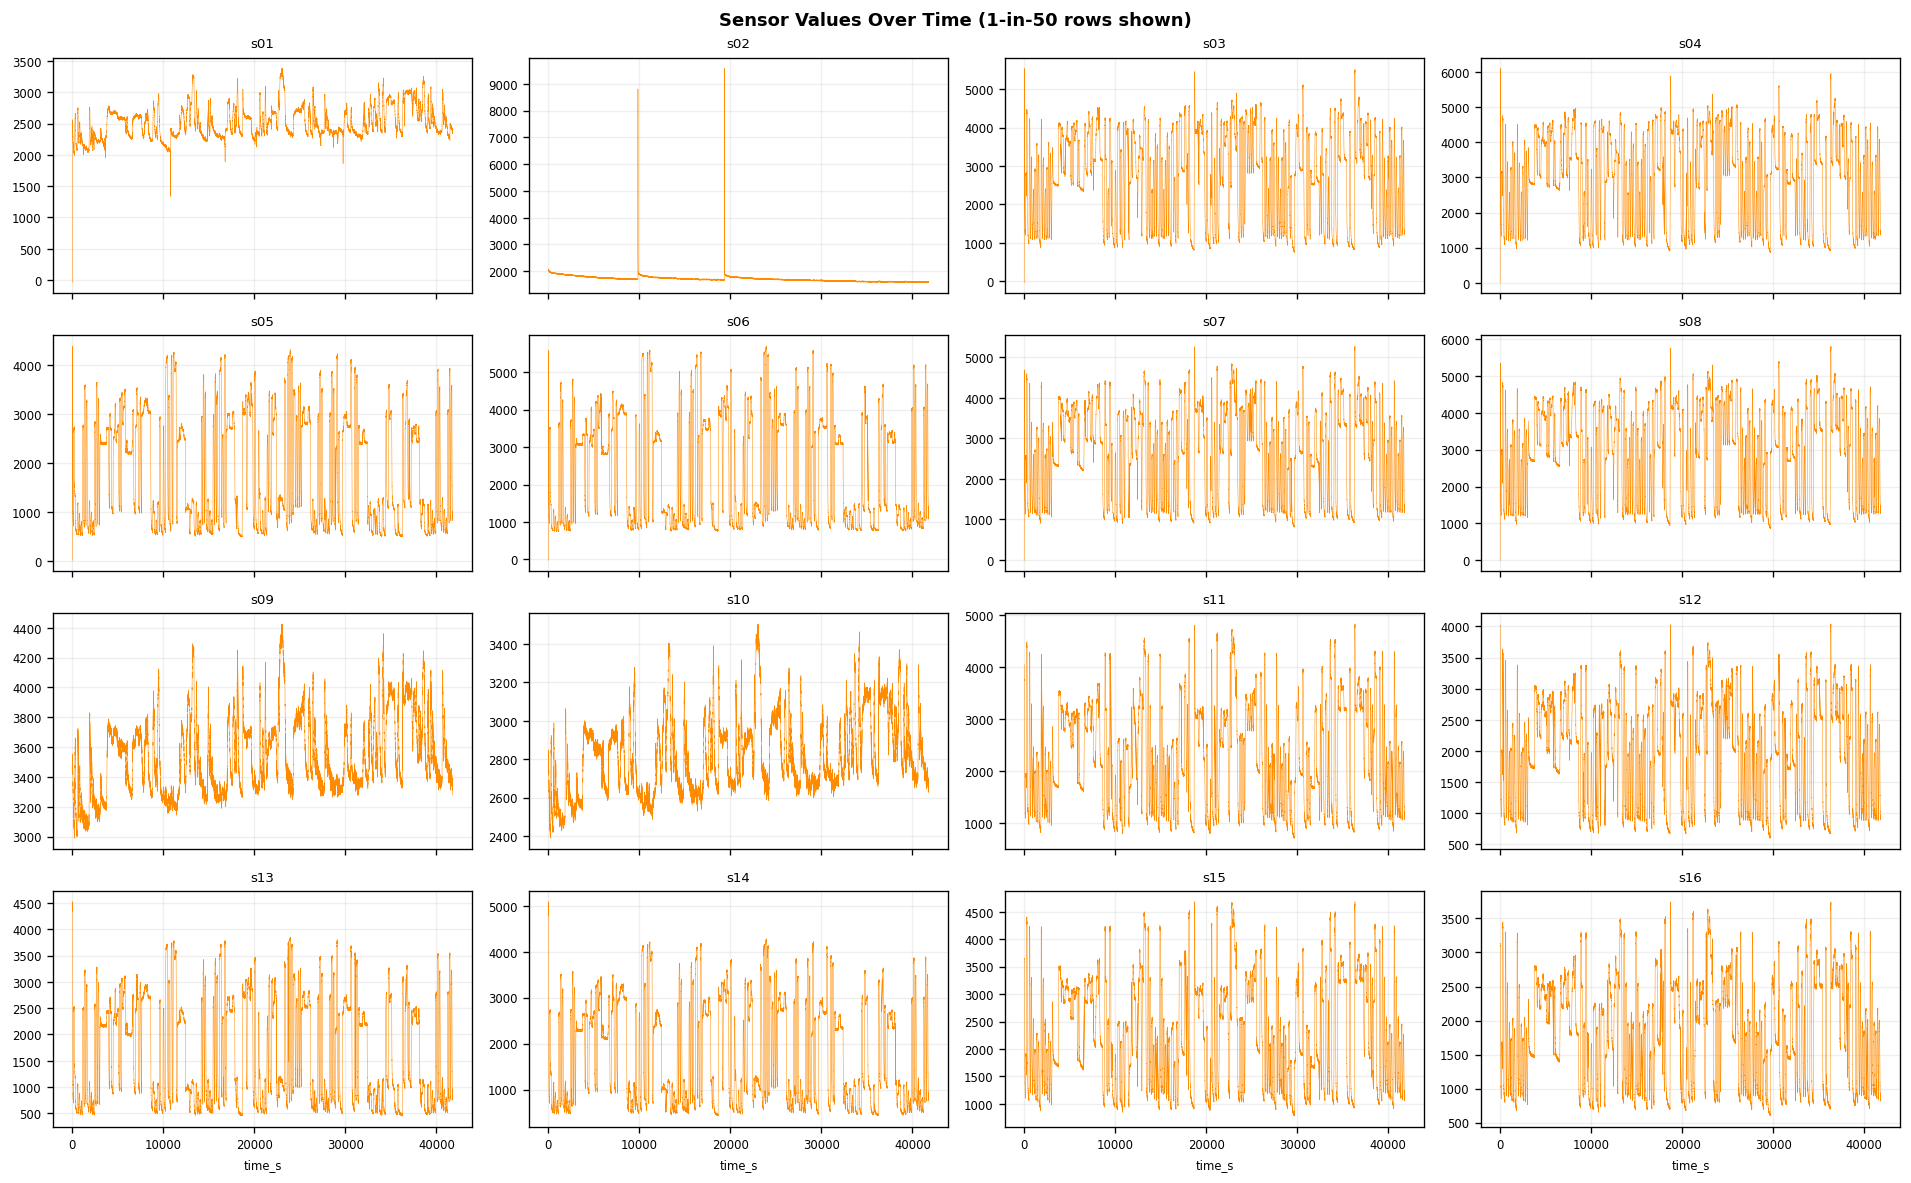

Saved: 02_sensor_timeseries.png


In [6]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
fig.suptitle(f'Sensor Values Over Time (1-in-{PLOT_STRIDE} rows shown)', fontweight='bold')

for ax, sensor in zip(axes.flat, SENSORS):
    ax.plot(ds[TIME], ds[sensor], linewidth=0.3, color='darkorange', rasterized=True)
    ax.set_title(sensor, fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

for ax in axes[-1]:
    ax.set_xlabel('time_s', fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_sensor_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 02_sensor_timeseries.png')

## 6. Sensor Distributions (Boxplot)

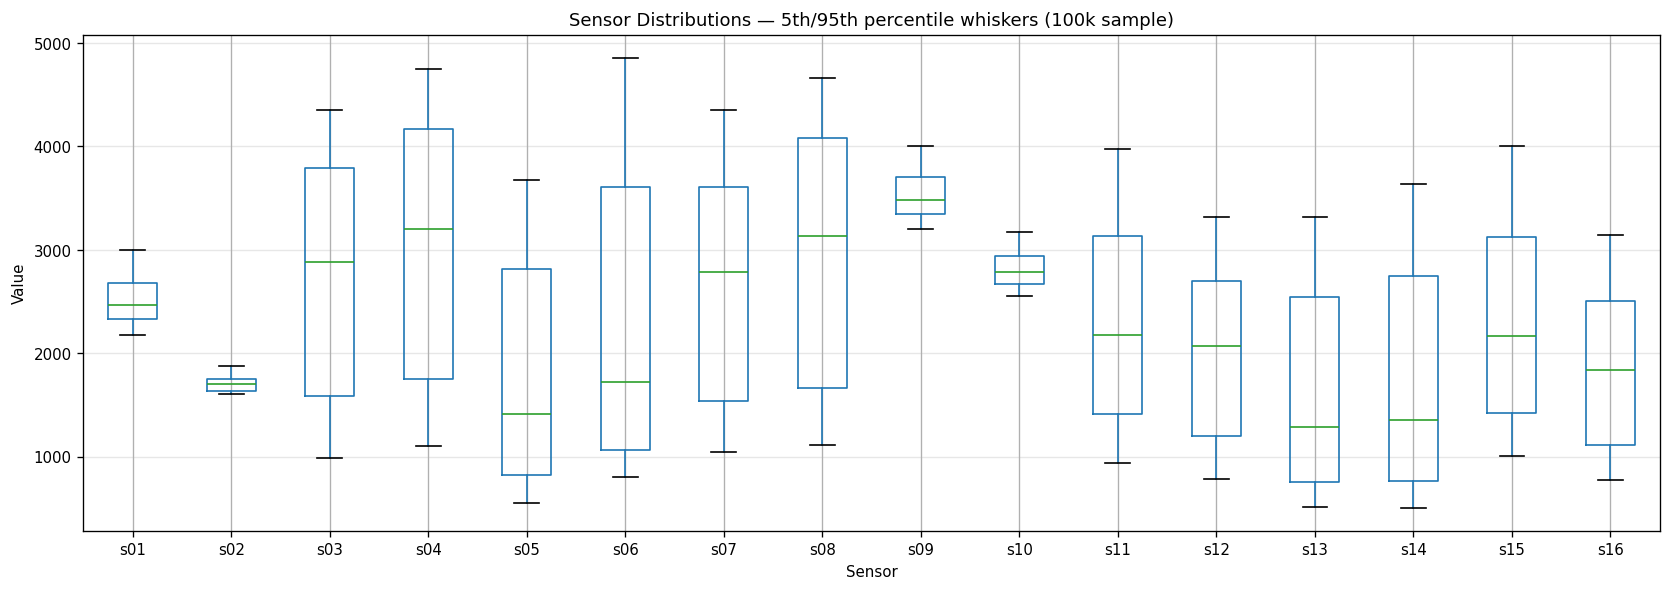

Saved: 02_sensor_boxplot.png


In [7]:
# Sample for boxplot (full 4M rows makes it slow)
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(df), size=100_000, replace=False)
sample_idx.sort()  # preserve temporal order in sample
df_sample = df.iloc[sample_idx]

fig, ax = plt.subplots(figsize=(14, 5))
df_sample[SENSORS].boxplot(ax=ax, sym='', whis=[5, 95])
ax.set_title('Sensor Distributions — 5th/95th percentile whiskers (100k sample)')
ax.set_xlabel('Sensor')
ax.set_ylabel('Value')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_sensor_boxplot.png', bbox_inches='tight')
plt.show()
print('Saved: 02_sensor_boxplot.png')

## 7. Sensor–Target Correlations (Pearson)

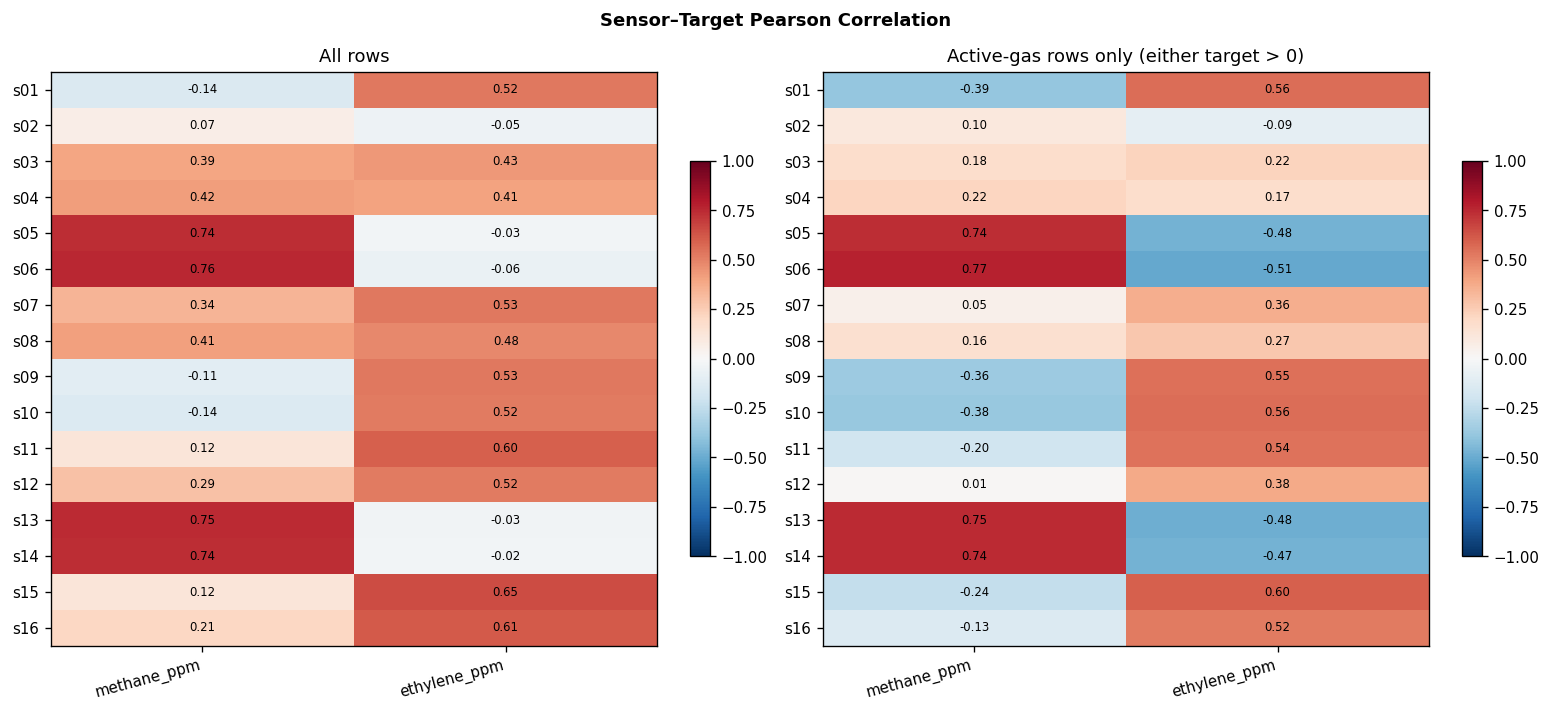

Saved: 02_sensor_target_correlation.png

Correlation with methane_ppm (all rows):
s06    0.757718
s13    0.745570
s14    0.741205
s05    0.737518
s04    0.418509
s08    0.408273
s03    0.394419
s07    0.340571
s12    0.293431
s16    0.210210
s15    0.121893
s11    0.121874
s02    0.067951
s09   -0.108314
s10   -0.136624
s01   -0.144040

Correlation with ethylene_ppm (all rows):
s15    0.652596
s16    0.612186
s11    0.599878
s09    0.531018
s07    0.527484
s01    0.523701
s10    0.519955
s12    0.517674
s08    0.479482
s03    0.430955
s04    0.405503
s14   -0.023921
s05   -0.027998
s13   -0.032137
s02   -0.053148
s06   -0.063897


In [8]:
# Compute on full dataset
corr_all = df[SENSORS + TARGETS].corr(method='pearson')

# Sensor-target slice only
corr_st = corr_all.loc[SENSORS, TARGETS]

# Also compute on active-gas rows only
corr_active = df.loc[active_any, SENSORS + TARGETS].corr(method='pearson').loc[SENSORS, TARGETS]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Sensor–Target Pearson Correlation', fontweight='bold')

for ax, corr_data, title in zip(axes,
                                 [corr_st, corr_active],
                                 ['All rows', 'Active-gas rows only (either target > 0)']):
    im = ax.imshow(corr_data.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(TARGETS)))
    ax.set_xticklabels(TARGETS, rotation=15, ha='right')
    ax.set_yticks(range(len(SENSORS)))
    ax.set_yticklabels(SENSORS)
    ax.set_title(title)
    for i in range(len(SENSORS)):
        for j in range(len(TARGETS)):
            ax.text(j, i, f'{corr_data.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_sensor_target_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: 02_sensor_target_correlation.png')
print('\nCorrelation with methane_ppm (all rows):')
print(corr_st['methane_ppm'].sort_values(ascending=False).to_string())
print('\nCorrelation with ethylene_ppm (all rows):')
print(corr_st['ethylene_ppm'].sort_values(ascending=False).to_string())

## 8. Sensor–Sensor Correlation Heatmap

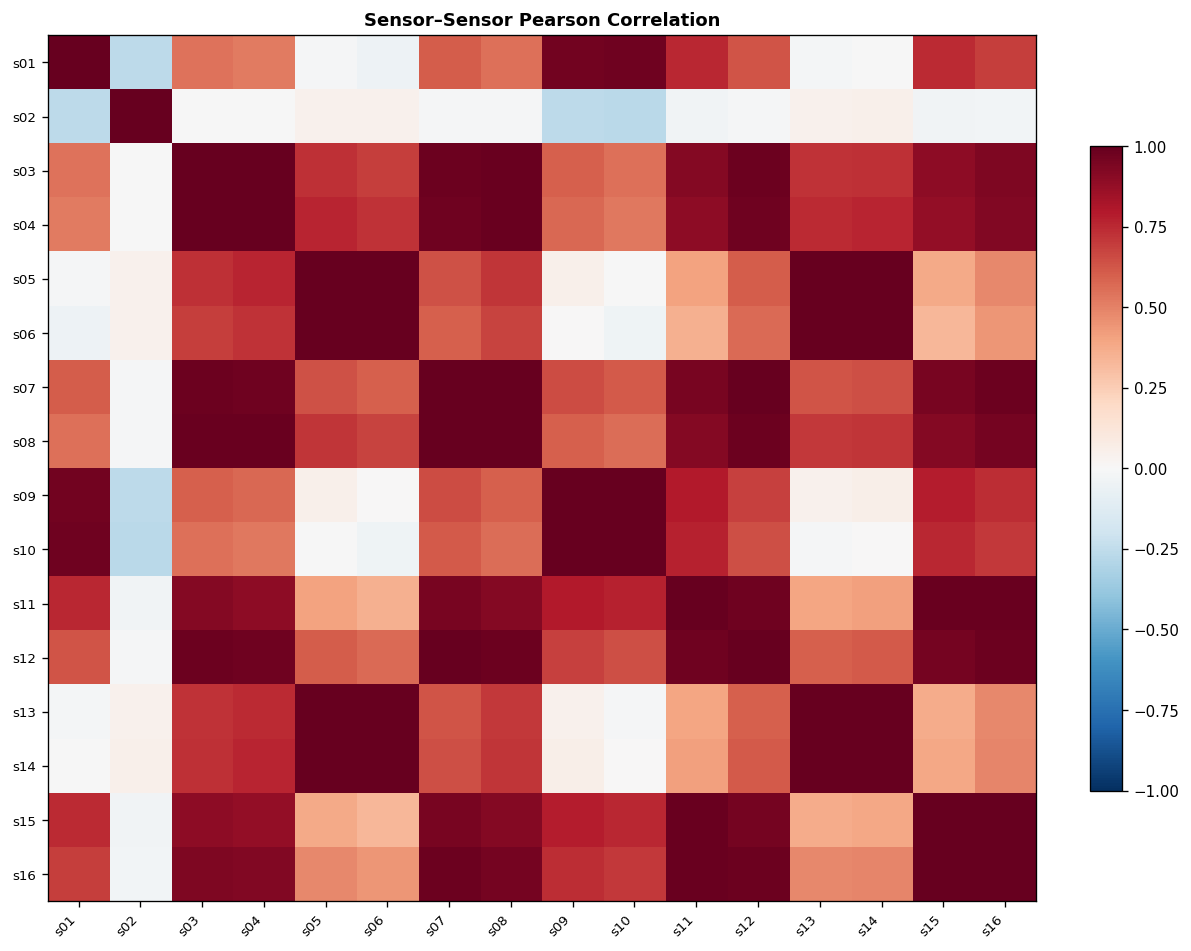

Saved: 02_sensor_sensor_correlation.png

Highly correlated sensor pairs (|r| > 0.95): 29
  s03 ↔ s04 : r = 0.999
  s05 ↔ s14 : r = 0.999
  s13 ↔ s14 : r = 0.999
  s05 ↔ s06 : r = 0.998
  s05 ↔ s13 : r = 0.998
  s06 ↔ s13 : r = 0.997
  s06 ↔ s14 : r = 0.996
  s09 ↔ s10 : r = 0.996
  s07 ↔ s08 : r = 0.995
  s07 ↔ s12 : r = 0.993
  s15 ↔ s16 : r = 0.992
  s11 ↔ s15 : r = 0.99
  s03 ↔ s08 : r = 0.989
  s04 ↔ s08 : r = 0.987
  s11 ↔ s16 : r = 0.985
  s03 ↔ s07 : r = 0.983
  s03 ↔ s12 : r = 0.983
  s08 ↔ s12 : r = 0.983
  s12 ↔ s16 : r = 0.982
  s07 ↔ s16 : r = 0.981
  s04 ↔ s07 : r = 0.976
  s04 ↔ s12 : r = 0.975
  s01 ↔ s09 : r = 0.969
  s01 ↔ s10 : r = 0.969
  s11 ↔ s12 : r = 0.969
  s08 ↔ s16 : r = 0.957
  s12 ↔ s15 : r = 0.957
  s07 ↔ s11 : r = 0.951
  s07 ↔ s15 : r = 0.951


In [9]:
corr_ss = df[SENSORS].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_ss.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(SENSORS)))
ax.set_xticklabels(SENSORS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(SENSORS)))
ax.set_yticklabels(SENSORS, fontsize=8)
ax.set_title('Sensor–Sensor Pearson Correlation', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_sensor_sensor_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: 02_sensor_sensor_correlation.png')

# Identify highly correlated sensor pairs (|r| > 0.95)
high_corr_pairs = []
for i in range(len(SENSORS)):
    for j in range(i + 1, len(SENSORS)):
        r = corr_ss.values[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append((SENSORS[i], SENSORS[j], round(r, 3)))

print(f'\nHighly correlated sensor pairs (|r| > 0.95): {len(high_corr_pairs)}')
for s1, s2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f'  {s1} ↔ {s2} : r = {r}')

## 9. Sensor Response During Active-Gas Periods

Check whether sensor values are meaningfully different in active-gas vs baseline periods.

     baseline_mean  active_mean  delta_mean   delta_%
s01      2431.6452    2563.5390    131.8937    5.4241
s02      1710.6710    1711.8305      1.1595    0.0678
s03      1852.3774    3199.7838   1347.4064   72.7393
s04      2050.2083    3518.9428   1468.7345   71.6383
s05      1086.4793    2243.9839   1157.5046  106.5372
s06      1416.5090    2861.6702   1445.1611  102.0227
s07      1769.9695    3140.8088   1370.8392   77.4499
s08      1923.7431    3496.1598   1572.4168   81.7374
s09      3440.8456    3591.2876    150.4420    4.3722
s10      2754.1072    2858.0220    103.9147    3.7731
s11      1641.7310    2625.0209    983.2899   59.8935
s12      1389.1409    2336.0684    946.9275   68.1664
s13       988.9621    2029.8624   1040.9003  105.2518
s14      1028.3134    2187.5853   1159.2719  112.7353
s15      1603.1694    2655.5492   1052.3797   65.6437
s16      1263.5588    2156.8003    893.2416   70.6925


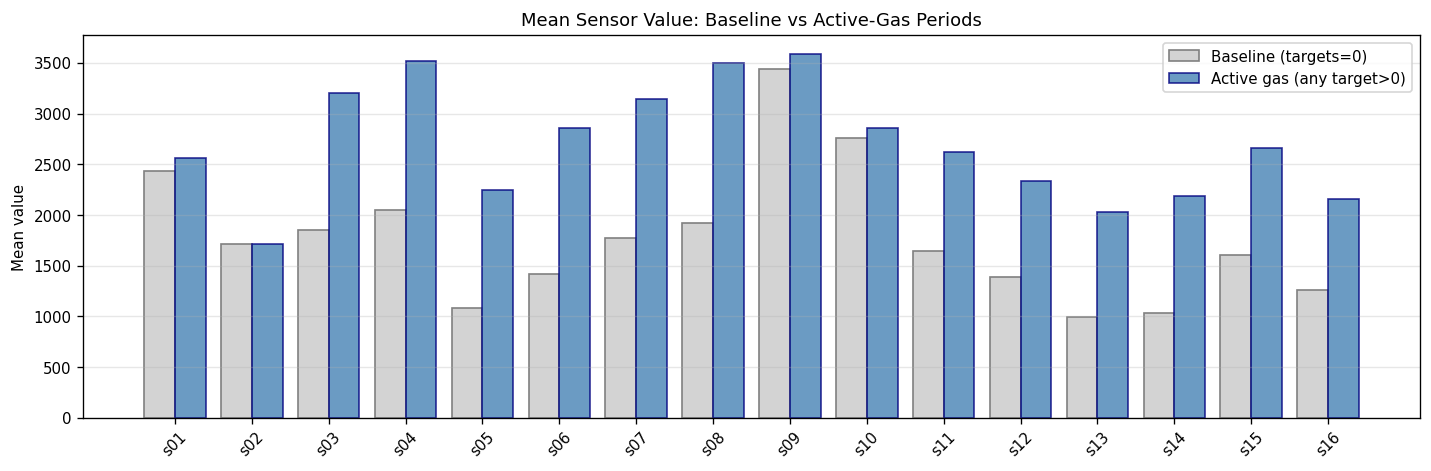

Saved: 02_sensor_response_baseline_vs_active.png


In [10]:
means_baseline = df.loc[~active_any, SENSORS].mean()
means_active   = df.loc[active_any,  SENSORS].mean()
delta = (means_active - means_baseline).rename('delta_mean')
delta_pct = ((means_active - means_baseline) / means_baseline.abs().replace(0, np.nan) * 100).rename('delta_%')

summary = pd.concat([means_baseline.rename('baseline_mean'),
                     means_active.rename('active_mean'),
                     delta, delta_pct], axis=1).round(4)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(SENSORS))
ax.bar(x - 0.2, means_baseline, width=0.4, label='Baseline (targets=0)', color='lightgray', edgecolor='gray')
ax.bar(x + 0.2, means_active,   width=0.4, label='Active gas (any target>0)', color='steelblue', edgecolor='navy', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(SENSORS, rotation=45)
ax.set_title('Mean Sensor Value: Baseline vs Active-Gas Periods')
ax.set_ylabel('Mean value')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_sensor_response_baseline_vs_active.png', bbox_inches='tight')
plt.show()
print('Saved: 02_sensor_response_baseline_vs_active.png')

## 10. EDA Decision Point — Summary

Run this cell last. Fill in the printed findings, then save the memo.

In [11]:
# Top 5 sensors by absolute correlation with each target (all rows)
top_methane  = corr_st['methane_ppm'].abs().sort_values(ascending=False).head(5)
top_ethylene = corr_st['ethylene_ppm'].abs().sort_values(ascending=False).head(5)

print('Top 5 sensors by |correlation| with methane_ppm:')
print(top_methane.to_string())
print('\nTop 5 sensors by |correlation| with ethylene_ppm:')
print(top_ethylene.to_string())
print(f'\nHighly correlated sensor pairs (|r|>0.95): {len(high_corr_pairs)}')

Top 5 sensors by |correlation| with methane_ppm:
s06    0.757718
s13    0.745570
s14    0.741205
s05    0.737518
s04    0.418509

Top 5 sensors by |correlation| with ethylene_ppm:
s15    0.652596
s16    0.612186
s11    0.599878
s09    0.531018
s07    0.527484

Highly correlated sensor pairs (|r|>0.95): 29


## 11. Save EDA Memo

In [12]:
MEMO_PATH.parent.mkdir(parents=True, exist_ok=True)

top_m_lines = [f'  - {s}: r = {corr_st.loc[s, "methane_ppm"]:.3f}' for s in top_methane.index]
top_e_lines = [f'  - {s}: r = {corr_st.loc[s, "ethylene_ppm"]:.3f}' for s in top_ethylene.index]
hc_lines    = [f'  - {s1} ↔ {s2}: r = {r}' for s1, s2, r in high_corr_pairs] or ['  - None']

lines = [
    '# 02 — EDA Summary',
    '',
    '**Date:** 2026-05-18',
    '**Dataset:** data/processed/ethylene_methane.parquet',
    '',
    '---',
    '',
    '## Gas Activity Breakdown',
    f'- Rows with methane_ppm  > 0 : {active_methane.sum():,}  ({active_methane.mean()*100:.1f}%)',
    f'- Rows with ethylene_ppm > 0 : {active_ethylene.sum():,}  ({active_ethylene.mean()*100:.1f}%)',
    f'- Rows with either target > 0: {active_any.sum():,}  ({active_any.mean()*100:.1f}%)',
    f'- Rows with both targets  > 0: {active_both.sum():,}  ({active_both.mean()*100:.1f}%)',
    '',
    '## Sensor–Target Correlations (Pearson, all rows)',
    'Top 5 for methane_ppm:',
] + top_m_lines + [
    'Top 5 for ethylene_ppm:',
] + top_e_lines + [
    '',
    '## Highly Correlated Sensor Pairs (|r| > 0.95)',
] + hc_lines + [
    '',
    '## Figures Saved',
    '- `results/figures/02_target_distributions.png`',
    '- `results/figures/02_target_timeseries.png`',
    '- `results/figures/02_regime_map.png`',
    '- `results/figures/02_sensor_timeseries.png`',
    '- `results/figures/02_sensor_boxplot.png`',
    '- `results/figures/02_sensor_target_correlation.png`',
    '- `results/figures/02_sensor_sensor_correlation.png`',
    '- `results/figures/02_sensor_response_baseline_vs_active.png`',
    '',
    '---',
    '',
    '## Feature Engineering Decision Point',
    '<!-- Fill in after reviewing figures -->',
    '',
    '**What the data suggests:**',
    '- [ ] Some sensors show clear response to gas presence (see bar chart)',
    '- [ ] High inter-sensor correlation found — possible redundancy (see heatmap)',
    '- [ ] Sensor drift visible over time (see time-series plots)',
    '- [ ] Target distributions are right-skewed / multi-modal',
    '',
    '**Proposed feature engineering (to confirm with supervisor):**',
    '- [ ] Use raw sensors as-is (no engineered features)',
    '- [ ] Add lag features (requires approval — do not create blindly)',
    '- [ ] Drop highly correlated sensors',
    '- [ ] Other: ___',
    '',
    '**Verdict:** <!-- Awaiting user approval to proceed to feature engineering -->',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\02_eda_summary.md


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

SEED        = 42
DATA_PATH   = Path('../data/processed/ethylene_methane.parquet')
FIG_DIR     = Path('../results/figures')
MEMO_PATH   = Path('../results/memos/02_eda_summary.md')

FIG_DIR.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

PLOT_STRIDE = 50

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print("Setup complete.")


Setup complete.
